# 02 — Qualidade das Fontes de Dados

**Objetivo:** comparar a qualidade dos diferentes sistemas de origem com base
na taxa de entrega de mensagens (`status ∈ {delivered, read}`).

Trabalhamos a partir do *DataFrame* `disparos_sistema.parquet`, gerado pelo
notebook `01_preprocessing.ipynb`.

**Definição adotada:**
- **Telefone HighDelivery**: telefone com taxa de entrega (`status ∈ {delivered, read}`) ≥ **90%**.

## Roteiro
1. **Taxa de entrega bruta por sistema** (com IC de Wilson).
2. **Taxa média por telefone** (mitiga viés de volume).
3. **Probabilidade de `Telefone HighDelivery`** por sistema — abordagem final.



## Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from statsmodels.stats.proportion import proportion_confint

OUT_DIR = Path('../outputs/processed')

df_disparos_sistema = pd.read_parquet(OUT_DIR / 'disparos_sistema.parquet')
print(f'df_disparos_sistema: {df_disparos_sistema.shape}')

STATUS_SUCESSO = ['delivered', 'read']

df_disparos_sistema: (748675, 20)


## 1. Taxa de entrega bruta por sistema
Calculamos a proporção de disparos com status ∈ {delivered, read} e seu IC de Wilson.

In [2]:
def adiciona_ic_wilson(df: pd.DataFrame, count_col: str, total_col: str,
                       prefix: str = '') -> pd.DataFrame:
    """Adiciona colunas ci_low/ci_high/erro a partir de contagens."""
    lows, highs = [], []
    for _, row in df.iterrows():
        low, high = proportion_confint(row[count_col], row[total_col], method='wilson')
        lows.append(low)
        highs.append(high)
    df[f'{prefix}ci_low'] = lows
    df[f'{prefix}ci_high'] = highs
    return df


df_taxa_envio = (
    df_disparos_sistema
    .assign(sucesso=lambda x: x['status_disparo'].isin(STATUS_SUCESSO).astype(int))
    .groupby('sistema_nome')
    .agg(total_envios=('sucesso', 'count'), sucessos=('sucesso', 'sum'))
    .reset_index()
)
df_taxa_envio['taxa_entrega'] = df_taxa_envio['sucessos'] / df_taxa_envio['total_envios']
df_taxa_envio = adiciona_ic_wilson(df_taxa_envio, 'sucessos', 'total_envios')
df_taxa_envio['erro'] = df_taxa_envio['ci_high'] - df_taxa_envio['taxa_entrega']

df_taxa_envio.sort_values('taxa_entrega', ascending=False)

,sistema_nome,total_envios,sucessos,taxa_entrega,ci_low,ci_high,erro
4,Sistema E,197221,195089,0.989190,0.988724,0.989637,0.000447
3,Sistema D,6829,6560,0.960609,0.955731,0.964970,0.004361
1,Sistema B,243851,231503,0.949363,0.948485,0.950226,0.000863
2,Sistema C,19781,18760,0.948385,0.945214,0.951382,0.002997
0,Sistema A,170391,160362,0.941141,0.940014,0.942249,0.001108
5,Sistema F,110602,102076,0.922913,0.921326,0.924470,0.001557


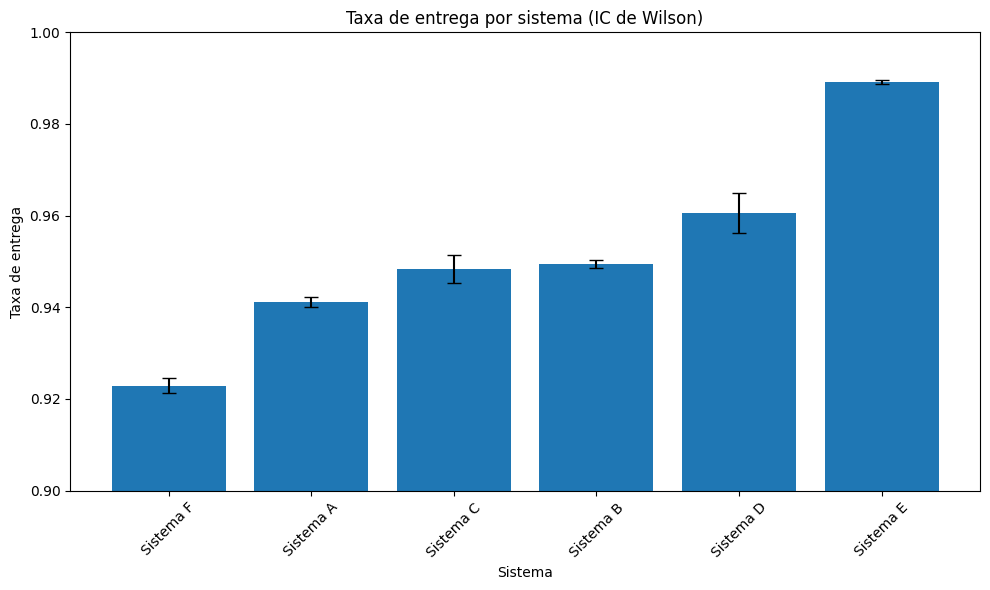

In [3]:
df_plot = df_taxa_envio.sort_values('taxa_entrega')

plt.figure(figsize=(10, 6))
plt.bar(df_plot['sistema_nome'], df_plot['taxa_entrega'],
        yerr=df_plot['erro'], capsize=5)
plt.ylim(0.9, 1.0)
plt.title('Taxa de entrega por sistema (IC de Wilson)')
plt.ylabel('Taxa de entrega')
plt.xlabel('Sistema')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Limitação:** a análise de taxa de entrega por sistema baseada no volume total de envios apresenta um viés importante, pois pode ser fortemente influenciada por um pequeno número de telefones com alto volume de disparos.

## 2. Taxa média de entrega por telefone
Cada telefone vira uma observação. Reduz o viés de volume.

In [4]:
df_tel = (
    df_disparos_sistema
    .groupby(['sistema_nome', 'telefone_numero'])
    .agg(
        total_envios=('status_disparo', 'count'),
        sucessos=('status_disparo', lambda x: x.isin(STATUS_SUCESSO).sum()),
    )
    .reset_index()
)
df_tel['taxa_entrega_tel'] = df_tel['sucessos'] / df_tel['total_envios']

df_stats_sistema = (
    df_tel.groupby('sistema_nome')['taxa_entrega_tel']
    .agg(media='mean', desvio='std',
         p10=lambda x: x.quantile(0.10),
         p25=lambda x: x.quantile(0.25),
         p50='median',
         p75=lambda x: x.quantile(0.75),
         p90=lambda x: x.quantile(0.90))
    .reset_index()
)
df_stats_sistema

KeyboardInterrupt: 

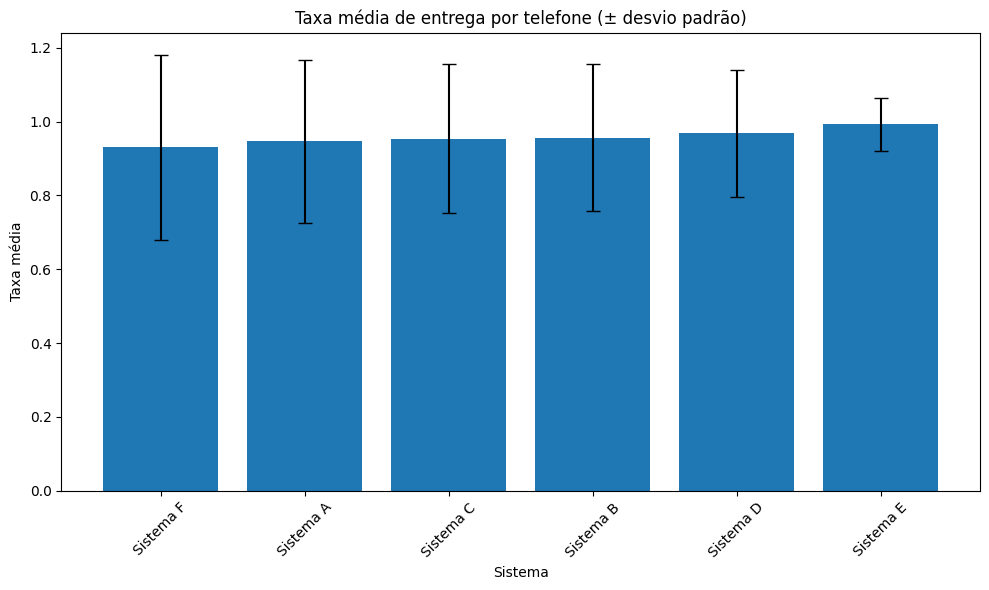

In [ ]:
df_plot = df_stats_sistema.sort_values('media')

plt.figure(figsize=(10, 6))
plt.bar(df_plot['sistema_nome'], df_plot['media'],
        yerr=df_plot['desvio'], capsize=5)
plt.title('Taxa média de entrega por telefone (± desvio padrão)')
plt.ylabel('Taxa média')
plt.xlabel('Sistema')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Limitação:** observa-se que as médias são elevadas e próximas entre si, enquanto os desvios padrão permanecem relativamente altos. Além disso, os percentis indicam que a grande maioria dos telefones apresenta taxa de entrega igual a 1, tornando as distribuições muito semelhantes entre os sistemas.
Em conjunto, esses fatores reduzem o poder discriminatório da análise.

## 3. Probabilidade de `Telefone HighDelivery` (taxa de entrega ≥ 90%)
Definimos como **Telefone HighDelivery** aquele com taxa de entrega ≥ 90%.

Para cada sistema estimamos `P(Telefone HighDelivery | sistema)` com IC de Wilson.

In [ ]:
LIMIAR_HIGH_DELIVERY = 0.9
df_tel['high_delivery'] = (df_tel['taxa_entrega_tel'] >= LIMIAR_HIGH_DELIVERY).astype(int)

df_high_delivery = (
    df_tel.groupby('sistema_nome')
    .agg(qtd_telefones=('telefone_numero', 'nunique'),
         telefones_high_delivery=('high_delivery', 'sum'))
    .reset_index()
)
df_high_delivery['prob_high_delivery'] = (
    df_high_delivery['telefones_high_delivery'] / df_high_delivery['qtd_telefones']
)
df_high_delivery = adiciona_ic_wilson(
    df_high_delivery, 'telefones_high_delivery', 'qtd_telefones'
)
df_high_delivery['erro'] = df_high_delivery['ci_high'] - df_high_delivery['prob_high_delivery']

df_high_delivery.sort_values('prob_high_delivery', ascending=False)

,sistema_nome,qtd_telefones,telefones_high_delivery,prob_high_delivery,ci_low,ci_high,erro
4,Sistema E,135266,133454,0.986604,0.985978,0.987203,0.000599
3,Sistema D,4680,4513,0.964316,0.958609,0.969261,0.004945
1,Sistema B,175516,167003,0.951497,0.950482,0.952492,0.000995
2,Sistema C,11770,11124,0.945115,0.940853,0.949086,0.003971
0,Sistema A,122918,115776,0.941896,0.940575,0.943190,0.001294
5,Sistema F,81348,75369,0.926501,0.924688,0.928274,0.001773


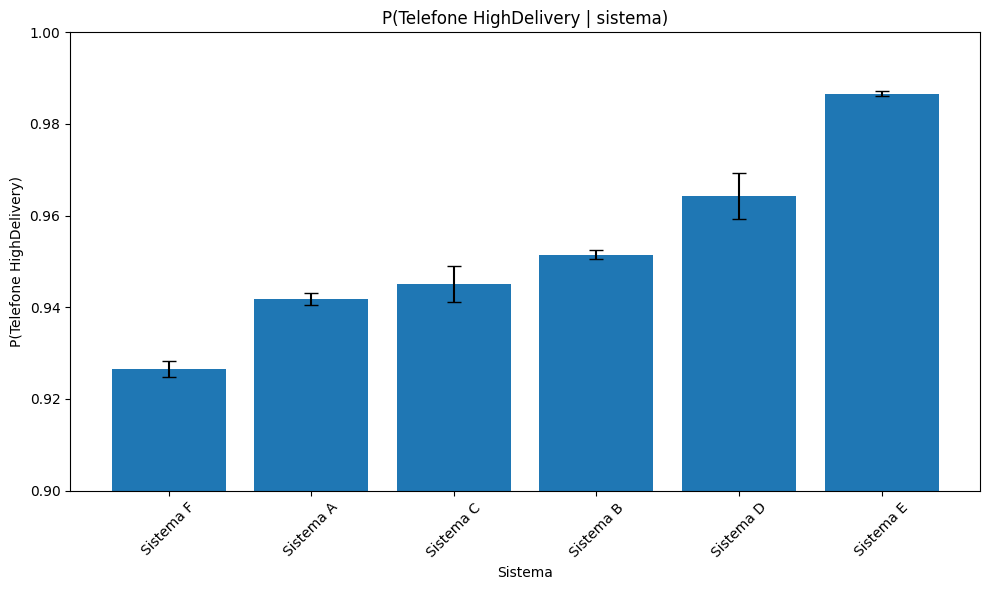

In [ ]:
df_plot = df_high_delivery.sort_values('prob_high_delivery')

plt.figure(figsize=(10, 6))
plt.bar(df_plot['sistema_nome'], df_plot['prob_high_delivery'],
        yerr=df_plot['erro'], capsize=5)
plt.ylim(0.9, 1.0)
plt.title('P(Telefone HighDelivery | sistema)')
plt.ylabel('P(Telefone HighDelivery)')
plt.xlabel('Sistema')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusão

Diante das limitações das análises anteriores, seja pelo viés de volume de envios, seja pela baixa capacidade discriminativa da taxa contínua por telefone, a abordagem foi reformulada para avaliar a qualidade dos sistemas com base na confiabilidade dos telefones. Para isso, classificou-se cada telefone como **Telefone HighDelivery** quando sua taxa de entrega é ≥ 90%, incorporando não apenas a ocorrência de sucesso, mas também a penalização de falhas.

Em seguida, foi estimada, para cada sistema, a probabilidade `P(Telefone HighDelivery | sistema)`, juntamente com intervalos de confiança, a fim de capturar a incerteza dessas estimativas.

Os resultados indicam que o Sistema E se destaca como o mais confiável, em linha com o observado na análise inicial, embora aquela estivesse sujeita a viés de volume. A variação entre o primeiro gráfico e este último é sutil, sugerindo que o viés não impactou significativamente os resultados iniciais, mas orientou a análise para uma abordagem mais robusta.